# 🌾 Wheat Phenology — V2 (GPU + EfficientNet + 2-Stage Fine-Tune)

**Hedef:** V1'deki **~%55 accuracy** değerini **>%70**'e çıkarmak.

### V1'e göre değişiklikler (neden?)

| # | Değişiklik | Neden |
|---|---|---|
| 1 | **EfficientNet-B0 backbone** (ResNet18 yerine) | Daha iyi özellik çıkarımı, benzer hız |
| 2 | **2-Aşamalı eğitim** (warmup → unfreeze) | Donuk CNN büyük sınır; aşama 2'de düşük LR ile fine-tune |
| 3 | **Attention pooling** (son frame yerine) | Tüm sequence'taki bilgiyi kullan, tek bir bulutlu frame kararı bozmasın |
| 4 | **Mixed Precision (AMP)** | GPU'da ~2x hız kazancı |
| 5 | **Daha uzun sequence (24) + küçük stride (6)** | Daha iyi temporal bağlam + daha fazla eğitim örneği |
| 6 | **RandAugment + Random Erasing + Mixup** | Augmentation çeşitliliği, overfitting azaltma |
| 7 | **Label smoothing + class weights** | Dengesiz sınıflar (PS0:1455 vs PS5:484) için |
| 8 | **AdamW + Cosine + Warmup** | Daha stabil optimizasyon |
| 9 | **Macro F1 tabanlı early stopping** | Accuracy ≠ dengeli öğrenme |
| 10 | **Eski framework.py ile 100% uyumlu** | V1 ile karşılaştırılabilir, aynı fold'lar |

### Pipeline
```
Görüntü dizisi → EfficientNet-B0 (fine-tune) → BiLSTM → Attention Pool → PS0-PS7
```


In [1]:
# !pip install "numpy<2" --upgrade
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# optional alternative if fragmentation continues:
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"

## 1 — Import & GPU Kontrolü

In [2]:
import importlib, os, re, json, math, random, warnings
import framework
importlib.reload(framework)
from framework import WheatFramework, generate_group_folds, save_model, save_results, run_fold_with_trainer

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler
import torchvision.transforms as T
import torchvision.models as tvm
from PIL import Image

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True  # Hız optimizasyonu

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA: {torch.version.cuda} | PyTorch: {torch.__version__}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  GPU bulunamadı! CPU üzerinde çok yavaş olacak. CUDA kurulumunu kontrol et.')

Device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA: 12.6 | PyTorch: 2.8.0+cu126
VRAM: 25.8 GB


## 2 — Yollar ve Çıktı Dizini

In [3]:
# ⚠️ Kendi makinenize göre güncelleyin
EXCEL_PATH  = r".\\labeling.xlsx"
DATA_PATH   = r".\\data"
RESULTS_DIR = "results_rnn_v2"

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Sonuçlar buraya yazılacak: {os.path.abspath(RESULTS_DIR)}")

Sonuçlar buraya yazılacak: c:\Users\PC\Desktop\AI_TARBIL\code\results_rnn_v2


## 3 — Veriyi Yükle

In [4]:
wf = WheatFramework(excel_path=EXCEL_PATH, root_dir=DATA_PATH)
meta_df = wf.get_dataframe()

if meta_df.empty:
    raise RuntimeError("Hiç görüntü eşleşmedi. Excel/dizin yollarını ve tarih formatını kontrol edin.")

print(f"\nToplam eşleşen görüntü: {len(meta_df)}")
print(f"Grup sayısı (station-year): {meta_df['group_id'].nunique()}")
print(f"Etiket dağılımı:\n{meta_df['label'].value_counts().to_string()}")

Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

## 4 — Dosya Adından Tarih Çıkar + Grup İçinde Sırala

RNN için **tarih sırası şart**. `framework.py` tarih tutmuyor, dosya adından çıkarıyoruz.

In [5]:
_DATE_RE = re.compile(r'(\d{4})[_-](\d{2})[_-](\d{2})|(\d{4})(\d{2})(\d{2})')

def extract_date(path: str) -> pd.Timestamp:
    m = _DATE_RE.search(os.path.basename(path))
    if not m:
        return pd.NaT
    if m.group(1):
        y, mo, d = m.group(1), m.group(2), m.group(3)
    else:
        y, mo, d = m.group(4), m.group(5), m.group(6)
    try:
        return pd.Timestamp(f"{y}-{mo}-{d}")
    except Exception:
        return pd.NaT

meta_df['img_date'] = meta_df['path'].apply(extract_date)
meta_df = meta_df.dropna(subset=['img_date']).copy()
meta_df = meta_df.sort_values(['group_id', 'img_date']).reset_index(drop=True)

print(f"Tarih çıkarma sonrası: {len(meta_df)} görüntü, {meta_df['group_id'].nunique()} grup")
print(f"Tarih aralığı: {meta_df['img_date'].min()} → {meta_df['img_date'].max()}")

Tarih çıkarma sonrası: 1742 görüntü, 10 grup
Tarih aralığı: 2013-11-03 00:00:00 → 2017-07-08 00:00:00


## 5 — Hiperparametreler

In [6]:
CFG = {
    # Görüntü
    "img_size":      224,
    "img_mean":      [0.485, 0.456, 0.406],
    "img_std":       [0.229, 0.224, 0.225],

    # CNN Backbone
    "cnn_backbone":  "efficientnet_b0",   # ResNet18'den daha güçlü
    "embed_dim":     1280,                # EffNet-B0 feature dim
    # Warmup aşamasında CNN donuk, sonra unfreeze olacak

    # Sequence
    "seq_len":       24,   # Daha uzun bağlam
    "stride":        6,    # Daha küçük stride → daha fazla eğitim sequence'ı
    "mode":          "last",   # son frame'in etiketi sequence etiketi

    # LSTM + Attention
    "hidden_dim":    256,
    "num_layers":    2,
    "dropout":       0.4,
    "bidirectional": True,
    "attn_dim":      128,     # Attention MLP boyutu

    # Eğitim
    "epochs_warmup":   5,      # Aşama 1: CNN donuk
    "epochs_finetune": 30,     # Aşama 2: CNN unfreeze
    "batch_size":      8,      # RTX 3060+ için 8, daha fazla VRAM varsa 16
    "lr_warmup":       1e-3,   # LSTM/FC için warmup LR
    "lr_finetune_cnn": 1e-5,   # Unfreeze aşamasında CNN için (düşük!)
    "lr_finetune_head":3e-4,   # Unfreeze aşamasında LSTM+FC için
    "weight_decay":    1e-4,
    "patience":        8,      # Early stopping (macro F1'e göre)
    "label_smoothing": 0.1,
    "mixup_alpha":     0.2,    # Sequence-level mixup
    "use_amp":         True,   # Mixed precision → 2x hız

    # Fold
    "n_train":       8,
    "n_test":        2,
    "num_folds":     5,
    "random_state":  42,
}

NUM_CLASSES = meta_df['label'].nunique()
LABEL_NAMES = sorted(meta_df['label'].unique())
LABEL2IDX   = {lbl: i for i, lbl in enumerate(LABEL_NAMES)}
IDX2LABEL   = {i: lbl for lbl, i in LABEL2IDX.items()}
print(f"Sınıf sayısı: {NUM_CLASSES}  →  {LABEL_NAMES}")

Sınıf sayısı: 8  →  ['PS0', 'PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'PS7']


## 6 — Dataset: Sliding Window + Güçlü Augmentation

V1'e göre farklar:
- Daha uzun sequence (24) ve daha küçük stride (6) → ~4x daha fazla eğitim örneği
- Augmentation: RandAugment, ColorJitter, Random Erasing
- Her frame'e bağımsız augment yerine **sequence boyunca tutarlı** random flip (temporal tutarlılık için)

In [7]:
class PhenologySequenceDatasetV2(Dataset):
    """
    Sliding window sequence dataset.
    - Tüm sequence'e aynı horizontal flip uygulanır (temporal consistency)
    - Frame başına: RandAugment + ColorJitter + Normalize + Random Erase
    - Validation için sadece resize + normalize
    """

    def __init__(self, df, label2idx, seq_len=24, stride=6,
                 img_size=224, img_mean=None, img_std=None,
                 train=True):
        self.df = df.reset_index(drop=True)
        self.label2idx = label2idx
        self.seq_len = seq_len
        self.stride = stride
        self.train = train
        self.img_size = img_size

        # Per-frame transforms
        if train:
            self.frame_tf = T.Compose([
                T.Resize((img_size, img_size)),
                T.RandAugment(num_ops=2, magnitude=7),
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
                T.ToTensor(),
                T.Normalize(mean=img_mean, std=img_std),
                T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
            ])
        else:
            self.frame_tf = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize(mean=img_mean, std=img_std),
            ])

        self.sequences = self._build_sequences()

    def _build_sequences(self):
        seqs = []
        for gid, grp in self.df.groupby('group_id', sort=False):
            grp = grp.sort_values('img_date').reset_index(drop=True)
            n = len(grp)
            if n < self.seq_len:
                pad = self.seq_len - n
                indices = [0] * pad + list(range(n))
                seqs.append((gid, grp, indices))
            else:
                for start in range(0, n - self.seq_len + 1, self.stride):
                    indices = list(range(start, start + self.seq_len))
                    seqs.append((gid, grp, indices))
        return seqs

    def __len__(self):
        return len(self.sequences)

    def _load_img(self, path):
        try:
            return Image.open(path).convert('RGB')
        except Exception:
            return Image.fromarray(np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))

    def __getitem__(self, idx):
        gid, grp, frame_indices = self.sequences[idx]
        # Sequence-level horizontal flip (tutarlılık için)
        do_flip = self.train and random.random() < 0.5

        frames = []
        for i in frame_indices:
            img = self._load_img(grp.iloc[i]['path'])
            if do_flip:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            frames.append(self.frame_tf(img))
        frames = torch.stack(frames)  # (T, C, H, W)

        label_str = grp.iloc[frame_indices[-1]]['label']
        label = torch.tensor(self.label2idx[label_str], dtype=torch.long)
        return frames, label

    # Sampler için her sequence'ın son-frame-etiketini çıkar
    def sequence_labels(self):
        return np.array([
            self.label2idx[grp.iloc[idx_list[-1]]['label']]
            for (_, grp, idx_list) in self.sequences
        ])

print("Dataset sınıfı hazır (V2).")

Dataset sınıfı hazır (V2).


## 7 — Model: EfficientNet-B0 + BiLSTM + Attention Pool

**Attention pooling:** LSTM tüm zaman adımlarını üretir; attention bunların ağırlıklı ortalamasını alır. Tek bir kötü frame (bulut, hareket bulanıklığı) prediction'ı baskın olarak belirleyemez.

In [8]:
class CNNEncoderV2(nn.Module):
    """EfficientNet-B0 feature extractor; unfreeze edilebilir."""

    def __init__(self, backbone='efficientnet_b0', pretrained=True):
        super().__init__()
        if backbone == 'efficientnet_b0':
            weights = tvm.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
            base = tvm.efficientnet_b0(weights=weights)
            self.features = base.features
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.embed_dim = 1280
        elif backbone == 'resnet18':
            weights = tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            base = tvm.resnet18(weights=weights)
            self.features = nn.Sequential(*list(base.children())[:-2])
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.embed_dim = 512
        else:
            raise ValueError(f"Bilinmeyen backbone: {backbone}")

    def set_frozen(self, frozen: bool):
        for p in self.features.parameters():
            p.requires_grad = not frozen

    def forward(self, x):          # x: (B, C, H, W)
        z = self.features(x)       # (B, C, H', W')
        z = self.pool(z).flatten(1)  # (B, embed_dim)
        return z


class AttentionPool(nn.Module):
    """Soft attention over LSTM time steps."""
    def __init__(self, d_in, d_hid=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_in, d_hid),
            nn.Tanh(),
            nn.Linear(d_hid, 1)
        )

    def forward(self, h):  # h: (B, T, D)
        scores = self.mlp(h).squeeze(-1)        # (B, T)
        weights = F.softmax(scores, dim=1)      # (B, T)
        ctx = torch.sum(weights.unsqueeze(-1) * h, dim=1)  # (B, D)
        return ctx, weights


class PhenologyRNNv2(nn.Module):
    """CNN (fine-tunable) → BiLSTM → AttentionPool → Linear."""

    def __init__(self, num_classes, cfg):
        super().__init__()
        self.encoder = CNNEncoderV2(backbone=cfg['cnn_backbone'], pretrained=True)
        # Başlangıçta donuk (warmup aşaması)
        self.encoder.set_frozen(True)

        directions = 2 if cfg['bidirectional'] else 1
        self.lstm = nn.LSTM(
            input_size=self.encoder.embed_dim,
            hidden_size=cfg['hidden_dim'],
            num_layers=cfg['num_layers'],
            batch_first=True,
            dropout=cfg['dropout'] if cfg['num_layers'] > 1 else 0.0,
            bidirectional=cfg['bidirectional']
        )
        d_lstm = cfg['hidden_dim'] * directions
        self.attn = AttentionPool(d_lstm, cfg['attn_dim'])

        self.classifier = nn.Sequential(
            nn.Dropout(cfg['dropout']),
            nn.Linear(d_lstm, d_lstm // 2),
            nn.GELU(),
            nn.Dropout(cfg['dropout']),
            nn.Linear(d_lstm // 2, num_classes)
        )

    def forward(self, frames):  # (B, T, C, H, W)
        B, T, C, H, W = frames.shape
        emb = self.encoder(frames.view(B*T, C, H, W)).view(B, T, -1)
        h, _ = self.lstm(emb)             # (B, T, D)
        ctx, _ = self.attn(h)             # (B, D)
        return self.classifier(ctx)       # (B, num_classes)


# Dry-run (shape test)
with torch.no_grad():
    _m = PhenologyRNNv2(NUM_CLASSES, CFG).to(DEVICE)
    _x = torch.randn(2, CFG['seq_len'], 3, CFG['img_size'], CFG['img_size']).to(DEVICE)
    _y = _m(_x)
    total_params = sum(p.numel() for p in _m.parameters())
    trainable_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f"Model çıktı şekli: {_y.shape}")
    print(f"Toplam parametre : {total_params/1e6:.2f} M")
    print(f"Warmup'ta trainable: {trainable_params/1e6:.2f} M  (CNN donuk)")
    del _m, _x, _y
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Model çıktı şekli: torch.Size([2, 8])
Toplam parametre : 8.93 M
Warmup'ta trainable: 4.93 M  (CNN donuk)


## 8 — Eğitim Yardımcıları (Mixup + AMP + Class Weights)

In [9]:
def mixup_data(frames, labels, alpha=0.2):
    """Sequence-level mixup: iki farklı sequence'i karıştır."""
    if alpha <= 0:
        return frames, labels, labels, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)  # simetrik → her zaman 0.5+
    idx = torch.randperm(frames.size(0), device=frames.device)
    mixed = lam * frames + (1 - lam) * frames[idx]
    return mixed, labels, labels[idx], lam


def mixup_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


def compute_class_weights(df, label2idx):
    counts = df['label'].value_counts()
    # Effective number of samples → daha yumuşak ağırlık
    beta = 0.9999
    eff_num = 1.0 - np.power(beta, np.array([counts.get(lbl, 1) for lbl in sorted(label2idx, key=label2idx.get)]))
    weights = (1.0 - beta) / np.maximum(eff_num, 1e-9)
    weights = weights / weights.sum() * len(label2idx)
    return torch.tensor(weights, dtype=torch.float)


def train_one_epoch(model, loader, optimizer, criterion, device, scaler,
                    mixup_alpha=0.0, desc='train'):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=desc, leave=False, ncols=110)
    for frames, labels in pbar:
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        if mixup_alpha > 0:
            frames, y_a, y_b, lam = mixup_data(frames, labels, mixup_alpha)
        with autocast("cuda", enabled=(scaler is not None)):
            logits = model(frames)
            if mixup_alpha > 0:
                loss = mixup_loss(criterion, logits, y_a, y_b, lam)
            else:
                loss = criterion(logits, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{total_loss/total:.3f}',
                          'acc':  f'{correct/total:.3f}'})
    pbar.close()
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc='eval'):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_true = [], []
    pbar = tqdm(loader, desc=desc, leave=False, ncols=110)
    for frames, labels in pbar:
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast("cuda", enabled=(device.type == 'cuda')):
            logits = model(frames)
            loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_true.extend(labels.cpu().tolist())
        pbar.set_postfix({'loss': f'{total_loss/total:.3f}',
                          'acc':  f'{correct/total:.3f}'})
    pbar.close()
    return total_loss / total, correct / total, all_preds, all_true


print("Eğitim yardımcıları hazır (mixup + AMP + tqdm progress bar).")

Eğitim yardımcıları hazır (mixup + AMP + tqdm progress bar).


## 9 — `rnn_trainer_v2`: Framework'e Bağlanan Fonksiyon

### İki aşamalı eğitim stratejisi

**Aşama 1 — Warmup (5 epoch):** CNN donuk, sadece LSTM + attention + classifier öğrenir. Hızlı, klasik transfer learning.

**Aşama 2 — Fine-tune (30 epoch):** CNN unfreeze, CNN için çok düşük LR (1e-5), LSTM/FC için normal LR (3e-4). Bu differential learning rate, bitki özelliklerine adapte olmak için şart.

In [10]:
def rnn_trainer_v2(train_df, test_df, fold_id):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_id}  |  Train: {len(train_df)} img,  Test: {len(test_df)} img")
    print(f"Train groups: {sorted(train_df['group_id'].unique().tolist())}")
    print(f"Test groups:  {sorted(test_df['group_id'].unique().tolist())}")
    print('='*60)

    # Datasets
    train_ds = PhenologySequenceDatasetV2(
        train_df, LABEL2IDX,
        seq_len=CFG['seq_len'], stride=CFG['stride'],
        img_size=CFG['img_size'], img_mean=CFG['img_mean'], img_std=CFG['img_std'],
        train=True,
    )
    test_ds = PhenologySequenceDatasetV2(
        test_df, LABEL2IDX,
        seq_len=CFG['seq_len'], stride=CFG['stride'],
        img_size=CFG['img_size'], img_mean=CFG['img_mean'], img_std=CFG['img_std'],
        train=False,
    )
    print(f"  Train sequences: {len(train_ds)} | Test sequences: {len(test_ds)}")

    # Weighted sampler → dengesizliği azaltan SAMPLER (loss-weight'a ek olarak)
    seq_labels = train_ds.sequence_labels()
    class_counts = np.bincount(seq_labels, minlength=NUM_CLASSES).astype(float)
    class_counts[class_counts == 0] = 1
    sample_weights = 1.0 / class_counts[seq_labels]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds, batch_size=CFG['batch_size'], sampler=sampler,
        num_workers=0, pin_memory=(DEVICE.type == 'cuda')
    )
    test_loader = DataLoader(
        test_ds, batch_size=CFG['batch_size'], shuffle=False,
        num_workers=0, pin_memory=(DEVICE.type == 'cuda')
    )

    # Model + Loss
    model = PhenologyRNNv2(NUM_CLASSES, CFG).to(DEVICE)
    class_w = compute_class_weights(train_df, LABEL2IDX).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=CFG['label_smoothing'])

    scaler = GradScaler("cuda") if (CFG['use_amp'] and DEVICE.type == 'cuda') else None
    history = []
    best_f1 = -1.0
    best_state = None
    best_preds, best_true = [], []
    patience_cnt = 0

    # ==================== AŞAMA 1: WARMUP (CNN donuk) ====================
    print("\n--- Aşama 1: CNN donuk warmup ---")
    model.encoder.set_frozen(True)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG['lr_warmup'], weight_decay=CFG['weight_decay']
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs_warmup'])

    for epoch in range(1, CFG['epochs_warmup'] + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE, scaler,
            mixup_alpha=CFG['mixup_alpha'],
            desc=f"F{fold_id} W{epoch:02d}/{CFG['epochs_warmup']} train"
        )
        va_loss, va_acc, preds_i, true_i = evaluate(
            model, test_loader, criterion, DEVICE,
            desc=f"F{fold_id} W{epoch:02d}/{CFG['epochs_warmup']} val"
        )
        scheduler.step()
        macro_f1 = f1_score(true_i, preds_i, average='macro', zero_division=0)

        history.append({'stage': 'warmup', 'epoch': epoch,
                        'tr_loss': tr_loss, 'tr_acc': tr_acc,
                        'va_loss': va_loss, 'va_acc': va_acc, 'va_f1': macro_f1})
        print(f"  W{epoch:02d}/{CFG['epochs_warmup']}  "
              f"tr_loss={tr_loss:.3f} tr_acc={tr_acc:.3f}  "
              f"va_loss={va_loss:.3f} va_acc={va_acc:.3f} va_f1={macro_f1:.3f}")

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_preds, best_true = preds_i, true_i

    # ==================== AŞAMA 2: FINE-TUNE (CNN açık) ====================
    print("\n--- Aşama 2: CNN fine-tune (differential LR) ---")
    model.encoder.set_frozen(False)

    # Differential LR: CNN → çok düşük, LSTM+Attn+FC → normal
    cnn_params = list(model.encoder.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith('encoder')]
    optimizer = optim.AdamW([
        {'params': cnn_params,  'lr': CFG['lr_finetune_cnn']},
        {'params': head_params, 'lr': CFG['lr_finetune_head']},
    ], weight_decay=CFG['weight_decay'])
    # Warmup (2 epoch) + Cosine
    warmup_epochs = 2
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        progress = (ep - warmup_epochs) / max(1, CFG['epochs_finetune'] - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    for epoch in range(1, CFG['epochs_finetune'] + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE, scaler,
            mixup_alpha=CFG['mixup_alpha'],
            desc=f"F{fold_id} F{epoch:02d}/{CFG['epochs_finetune']} train"
        )
        va_loss, va_acc, preds_i, true_i = evaluate(
            model, test_loader, criterion, DEVICE,
            desc=f"F{fold_id} F{epoch:02d}/{CFG['epochs_finetune']} val"
        )
        scheduler.step()
        macro_f1 = f1_score(true_i, preds_i, average='macro', zero_division=0)

        history.append({'stage': 'finetune', 'epoch': epoch,
                        'tr_loss': tr_loss, 'tr_acc': tr_acc,
                        'va_loss': va_loss, 'va_acc': va_acc, 'va_f1': macro_f1})

        print(f"  F{epoch:02d}/{CFG['epochs_finetune']}  "
              f"tr_loss={tr_loss:.3f} tr_acc={tr_acc:.3f}  "
              f"va_loss={va_loss:.3f} va_acc={va_acc:.3f} va_f1={macro_f1:.3f}")

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_preds, best_true = preds_i, true_i
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= CFG['patience']:
                print(f"  [Early stopping @ fine-tune epoch {epoch}]")
                break

    # En iyi model yükle
    model.load_state_dict(best_state)

    # Metrikler (en iyi model)
    preds_labels = [IDX2LABEL[i] for i in best_preds]
    true_labels  = [IDX2LABEL[i] for i in best_true]

    acc          = accuracy_score(best_true, best_preds)
    weighted_f1  = f1_score(best_true, best_preds, average='weighted', zero_division=0)
    macro_f1     = f1_score(best_true, best_preds, average='macro',    zero_division=0)
    per_class_f1 = f1_score(best_true, best_preds, average=None,       zero_division=0)

    metrics = {
        'fold': fold_id,
        'accuracy':    round(float(acc), 4),
        'weighted_f1': round(float(weighted_f1), 4),
        'macro_f1':    round(float(macro_f1), 4),
        'per_class_f1': {IDX2LABEL[i]: round(float(v), 4)
                         for i, v in enumerate(per_class_f1)},
    }

    print(f"\n  ✅ Fold {fold_id} (best):")
    print(f"     Accuracy    : {metrics['accuracy']:.4f}")
    print(f"     Weighted F1 : {metrics['weighted_f1']:.4f}")
    print(f"     Macro F1    : {metrics['macro_f1']:.4f}")

    pred_df = pd.DataFrame({
        'true_label': true_labels,
        'pred_label': preds_labels,
        'true_idx':   best_true,
        'pred_idx':   best_preds,
    })

    fold_dir = os.path.join(RESULTS_DIR, f'fold_{fold_id}')
    os.makedirs(fold_dir, exist_ok=True)
    pd.DataFrame(history).to_csv(os.path.join(fold_dir, 'training_history.csv'), index=False)

    # Bellek temizle
    del model, train_loader, test_loader, train_ds, test_ds
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return {'model': None, 'predictions': pred_df, 'metrics': metrics}
    # Not: model'i None dönüyoruz çünkü her fold'da diske yazmak VRAM şişirir.
    # İstersen trainer'ın sonuna model döndürmeyi ekle ve save_model_flag=True kullan.

print("rnn_trainer_v2 hazır.")

rnn_trainer_v2 hazır.


## 10 — Fold'ları Çalıştır

In [11]:
folds = generate_group_folds(
    meta_df,
    group_col='group_id',
    n_train=CFG['n_train'],
    n_test=CFG['n_test'],
    num_folds=CFG['num_folds'],
    random_state=CFG['random_state']
)
print(f"Oluşturulan fold sayısı: {len(folds)}")

all_results = []
fold_bar = tqdm(list(enumerate(folds, 1)), desc='Folds', ncols=110)
for fold_id, (train_idx, test_idx) in fold_bar:
    fold_bar.set_postfix({'current': f'fold {fold_id}/{len(folds)}'})
    result = run_fold_with_trainer(
        meta_df,
        train_idx=train_idx,
        test_idx=test_idx,
        trainer_fn=rnn_trainer_v2,
        out_dir=RESULTS_DIR,
        fold_id=fold_id,
        save_model_flag=False   # VRAM/disk ekonomisi için
    )
    all_results.append(result)
fold_bar.close()

Oluşturulan fold sayısı: 5


Folds:   0%|                                                                            | 0/5 [00:00<?, ?it/s]


FOLD 1  |  Train: 1361 img,  Test: 381 img
Train groups: [1, 2, 3, 4, 5, 6, 8, 10]
Test groups:  [7, 9]
  Train sequences: 201 | Test sequences: 57

--- Aşama 1: CNN donuk warmup ---


F1 W01/5 train:   0%|                                                                  | 0/26 [00:00<?, ?it/s]

F1 W01/5 val:   0%|                                                                     | 0/8 [00:00<?, ?it/s]

...

F3 F01/30 train:   0%|                                                                 | 0/26 [00:00<?, ?it/s]

F3 F01/30 val:   0%|                                                                    | 0/7 [00:00<?, ?it/s]

  F01/30  tr_loss=1.304 tr_acc=0.546  va_loss=1.682 va_acc=0.358 va_f1=0.300


F3 F02/30 train:   0%|                                                                 | 0/26 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 11 — Sonuçları Özetle

In [ ]:
metrics_list = [r['metrics'] for r in all_results]
summary = pd.DataFrame([
    {
        'fold':        m['fold'],
        'accuracy':    m['accuracy'],
        'weighted_f1': m['weighted_f1'],
        'macro_f1':    m['macro_f1'],
    } for m in metrics_list
])
summary.loc['mean'] = summary.mean(numeric_only=True)
summary.loc['std']  = summary.std(numeric_only=True)

print("\n📊 V2 Fold Özet Tablosu")
print(summary.to_string())

summary.to_csv(os.path.join(RESULTS_DIR, 'fold_summary.csv'))

# V1 ile karşılaştırma
v1_path = os.path.join('results_rnn', 'fold_summary.csv')
if os.path.exists(v1_path):
    v1 = pd.read_csv(v1_path, index_col=0)
    print("\n🔁 V1 vs V2 (mean):")
    print(f"  V1 acc = {v1.loc['mean', 'accuracy']:.4f}, macro_f1 = {v1.loc['mean', 'macro_f1']:.4f}")
    print(f"  V2 acc = {summary.loc['mean', 'accuracy']:.4f}, macro_f1 = {summary.loc['mean', 'macro_f1']:.4f}")
    acc_delta = summary.loc['mean', 'accuracy'] - v1.loc['mean', 'accuracy']
    f1_delta  = summary.loc['mean', 'macro_f1'] - v1.loc['mean', 'macro_f1']
    print(f"  Δacc = {acc_delta:+.4f}, Δmacro_f1 = {f1_delta:+.4f}")
else:
    print("\n(V1 sonucu bulunamadı - karşılaştırma yapılmadı)")


📊 V2 Fold Özet Tablosu
          fold  accuracy  weighted_f1  macro_f1
0     1.000000  0.561400     0.558100  0.457200
1     2.000000  0.370400     0.347000  0.329200
2     3.000000  0.471700     0.463500  0.470100
3     4.000000  0.580000     0.560000  0.561100
4     5.000000  0.641500     0.627500  0.617600
mean  3.000000  0.525000     0.511220  0.487040
std   1.414214  0.094514     0.097307  0.098612

🔁 V1 vs V2 (mean):
  V1 acc = 0.4374, macro_f1 = 0.3722
  V2 acc = 0.5250, macro_f1 = 0.4870
  Δacc = +0.0876, Δmacro_f1 = +0.1148


## 12 — Görselleştirme

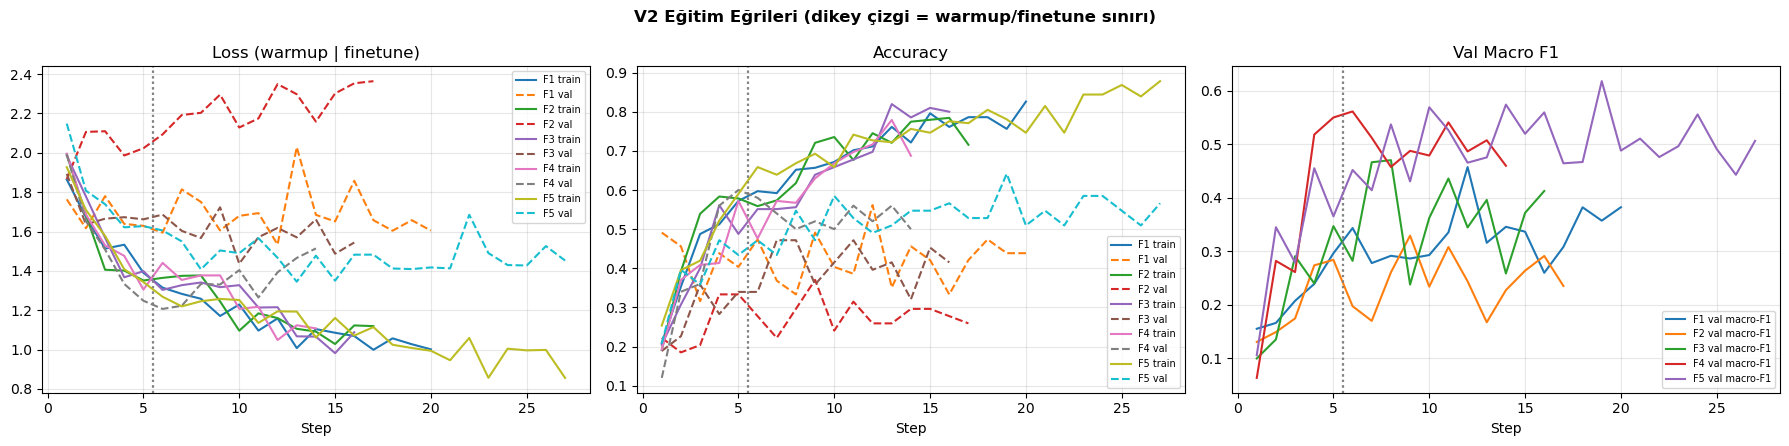

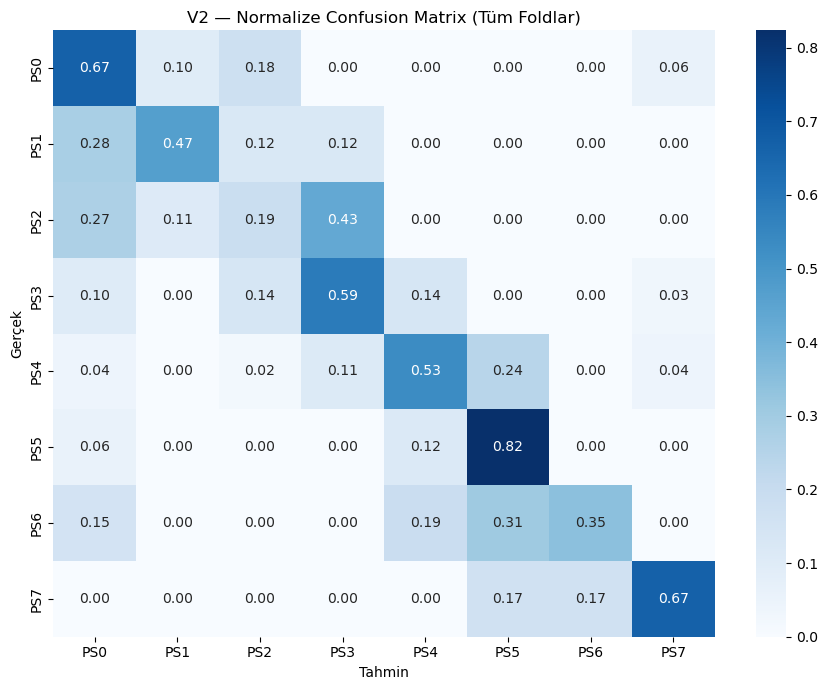


Classification report (V2):
              precision    recall  f1-score   support

         PS0       0.54      0.67      0.60        51
         PS1       0.62      0.47      0.54        32
         PS2       0.28      0.19      0.23        37
         PS3       0.40      0.59      0.48        29
         PS4       0.69      0.53      0.60        45
         PS5       0.37      0.82      0.51        17
         PS6       0.64      0.35      0.45        26
         PS7       0.77      0.67      0.71        30

    accuracy                           0.52       267
   macro avg       0.54      0.54      0.51       267
weighted avg       0.55      0.52      0.52       267



In [ ]:
# Eğitim eğrileri — aşama geçişini göster
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for fold_id in range(1, len(folds) + 1):
    hist_path = os.path.join(RESULTS_DIR, f'fold_{fold_id}', 'training_history.csv')
    if os.path.exists(hist_path):
        hist = pd.read_csv(hist_path)
        hist['step'] = range(1, len(hist) + 1)
        boundary = (hist['stage'] == 'warmup').sum()
        axes[0].plot(hist['step'], hist['tr_loss'], label=f'F{fold_id} train')
        axes[0].plot(hist['step'], hist['va_loss'], '--', label=f'F{fold_id} val')
        axes[1].plot(hist['step'], hist['tr_acc'], label=f'F{fold_id} train')
        axes[1].plot(hist['step'], hist['va_acc'], '--', label=f'F{fold_id} val')
        axes[2].plot(hist['step'], hist['va_f1'], label=f'F{fold_id} val macro-F1')
        for ax in axes:
            ax.axvline(boundary + 0.5, color='gray', linestyle=':', alpha=0.5)

axes[0].set_title('Loss (warmup | finetune)')
axes[1].set_title('Accuracy')
axes[2].set_title('Val Macro F1')
for ax, name in zip(axes, ['Loss', 'Acc', 'Macro F1']):
    ax.set_xlabel('Step'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.suptitle('V2 Eğitim Eğrileri (dikey çizgi = warmup/finetune sınırı)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_v2.png'), dpi=120)
plt.show()

# Aggregate confusion matrix
all_preds_agg, all_true_agg = [], []
for fold_id in range(1, len(folds) + 1):
    pred_path = os.path.join(RESULTS_DIR, f'fold_{fold_id}', 'predictions.csv')
    if os.path.exists(pred_path):
        p = pd.read_csv(pred_path)
        all_preds_agg.extend(p['pred_idx'].tolist())
        all_true_agg.extend(p['true_idx'].tolist())

if all_true_agg:
    cm = confusion_matrix(all_true_agg, all_preds_agg)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    ax.set_title('V2 — Normalize Confusion Matrix (Tüm Foldlar)')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_v2.png'), dpi=120)
    plt.show()

    print("\nClassification report (V2):")
    print(classification_report(all_true_agg, all_preds_agg,
                                target_names=LABEL_NAMES, zero_division=0))

## 13 — %70+ Ulaşmazsa Sonraki Adımlar

Aşağıdaki seçenekler bağımsız olarak denenebilir, hepsini aynı anda değil:

1. **Daha fazla veri** — 10 istasyondan fazlası eklenirse fold varyansı azalır.
2. **Bigger backbone** — `cnn_backbone = 'efficientnet_b2'` (1408 dim) veya `convnext_tiny` (768 dim, daha güçlü).
3. **Test-Time Augmentation (TTA)** — inference'ta 3-4 farklı augmentation ortalaması.
4. **Temporal attention (Transformer encoder)** — LSTM yerine `nn.TransformerEncoder` (2-4 layer, 4-8 head).
5. **Self-supervised pretrain** — CNN'i etiketsiz görüntülerle SimCLR/MAE ile önce adapte et, sonra supervised fine-tune.
6. **Ensemble** — farklı seed'lerle 3-5 model, softmax ortalaması.
7. **Curriculum learning** — önce kolay sınıflar (PS0, PS7 — tipik sınır evreler), sonra zor sınıflar.
8. **Weather/metadata features** — Excel'deki tarih bilgisi zaten sequence sırasında kullanılıyor ama explicit day-of-year (cos/sin encoding) feature eklenebilir.

### Fold varyansı için
V1'de fold 3 %41 vs fold 1 %68'di. Bu **istasyonlar arasında dağılım farkı** demek. Çözüm: daha fazla istasyon, veya **group-aware augmentation** (farklı istasyonları ağır normalize).
